# Identifying Latent Value Drivers with Factor Analysis

## Scenario
A survey captured 16 Likert-scale items (Q01–Q16) measuring customer attitudes
toward various aspects of a subscription service. Many of these items likely
reflect a smaller number of underlying constructs (e.g., "value for money",
"content quality", "convenience"). Your task is to run exploratory factor analysis
to identify these latent constructs and translate them into actionable messaging guidance.

## Your task
You will produce:
1. A fitted FactorAnalysis model with **3 factors**
2. A loadings table (items × factors)
3. The **top 3 items** per factor by absolute loading
4. A label/name for each factor based on its top items
5. 2–3 sentences per factor translating top items into messaging or segmentation guidance

## Requirements
- Use `survey_value_drivers.csv`
- Standardize the Likert items before fitting
- Use `sklearn.decomposition.FactorAnalysis(n_components=3, random_state=42)`
- Factor labels must reference specific items from the loadings table

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [5]:
# ── Step 1: Load and inspect the survey data ─────────────────────────────
df = pd.read_csv(SURVEY_PATH)
print(df.shape)
survey_cols = [c for c in df.columns if c != 'respondent_id']
print(f"Survey items ({len(survey_cols)}): {survey_cols}")
df[survey_cols].describe().round(2)

(6000, 17)
Survey items (16): ['Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16']


,Q01,Q02,Q03,Q04,Q05,Q06,Q07,Q08,Q09,Q10,Q11,Q12,Q13,Q14,Q15,Q16
count,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0
mean,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
std,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
50%,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
75%,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
max,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0


In [6]:
# ── Step 2: Standardize the survey items ─────────────────────────────────
# Standardize so all Likert items contribute equally regardless of mean/variance
X = df[survey_cols].astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (6000, 16)


In [7]:
# ── Step 3: Fit the factor model ─────────────────────────────────────────
# FactorAnalysis from sklearn; components_ is shape (n_factors, n_items) → transpose for loadings
fa = FactorAnalysis(n_components=3, random_state=42)
fa.fit(X_scaled)

loadings = pd.DataFrame(
    fa.components_.T,
    index=survey_cols,
    columns=['Factor 1', 'Factor 2', 'Factor 3']
)
print("Loadings table (rows=items, cols=factors):")
loadings.round(3)

Loadings table (rows=items, cols=factors):


,Factor 1,Factor 2,Factor 3
Q01,-0.450,0.585,-0.083
Q02,-0.489,0.508,-0.081
Q03,-0.473,0.518,-0.174
Q04,-0.499,0.448,-0.043
Q05,-0.505,-0.160,0.488
Q06,-0.521,-0.240,0.472
Q07,-0.566,-0.139,0.413
Q08,-0.551,-0.200,0.321
Q09,-0.533,-0.358,-0.381
Q10,-0.502,-0.273,-0.423


In [8]:
# ── Step 5: Top items per factor ────────────────────────────────────────────
# FactorAnalysis in scikit-learn does not enforce sign conventions.
# Factor 1 may show all-negative loadings — this means all items correlate
# in the same direction with Factor 1, suggesting a general-level factor
# (e.g., "overall engagement" or "overall value perception").
# A negative loading on Factor 1 simply means high scores on those items
# are associated with the opposite pole of the factor.
# The MAGNITUDE of the loading is what drives interpretation, not the sign alone.

for factor in loadings.columns:
    top3 = loadings[factor].abs().nlargest(3)
    print(f"\n{factor} — top 3 items (by |loading|):")
    for item in top3.index:
        val = loadings.loc[item, factor]
        direction = "+" if val > 0 else "−"
        print(f"  {item}: loading = {direction}{abs(val):.3f}")
    
    # Note if all loadings are same sign (general factor pattern)
    signs = loadings[factor].apply(lambda x: 1 if x > 0 else -1)
    if signs.nunique() == 1:
        print(f"  ⚠  All loadings on {factor} share the same sign — this suggests a")
        print("     general factor capturing overall response tendency.")
        print("     Interpretation: look at WHICH items load most heavily to name the construct.")



Factor 1 — top 3 items (by |loading|):
  Q14: loading = −0.581
  Q15: loading = −0.579
  Q16: loading = −0.577
  ⚠  All loadings on Factor 1 share the same sign — this suggests a
     general factor capturing overall response tendency.
     Interpretation: look at WHICH items load most heavily to name the construct.

Factor 2 — top 3 items (by |loading|):
  Q01: loading = +0.585
  Q03: loading = +0.518
  Q02: loading = +0.508

Factor 3 — top 3 items (by |loading|):
  Q05: loading = +0.488
  Q06: loading = +0.472
  Q10: loading = −0.423


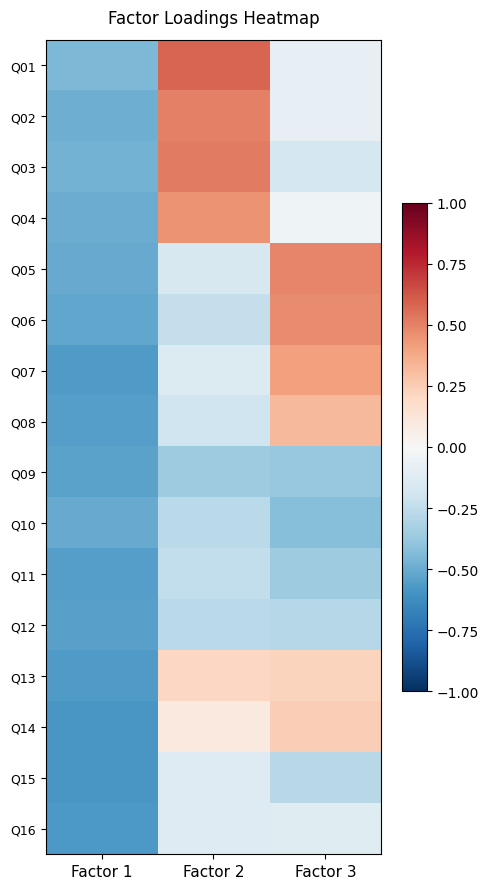

In [9]:
# ── Step 5: Loadings heatmap ─────────────────────────────────────────────
# Heatmap shows which items load strongly on each factor (red=positive, blue=negative)
fig, ax = plt.subplots(figsize=(5, 9))
im = ax.imshow(loadings.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.6)
ax.set_xticks(range(3))
ax.set_xticklabels(loadings.columns, fontsize=11)
ax.set_yticks(range(len(survey_cols)))
ax.set_yticklabels(survey_cols, fontsize=9)
ax.set_title("Factor Loadings Heatmap", pad=12)
plt.tight_layout()
plt.show()

## Factor Interpretation

For each of the three factors, provide:
- **Factor name** (a short label you assign based on the top items)
- **Top items** (the 3 items with the highest absolute loadings)
- **Business interpretation** (2–3 sentences): What does this factor represent?
  Which customer segment might score high on it? What messaging would resonate?

Example format:
> **Factor 1 — [Your Label]**
> Top items: Q03, Q07, Q11
> Customers who score high on this factor value…

In [10]:
# Interpretation guidance
print("Factor Naming Reference:")
print("  Factor 1: top items Q14, Q15, Q16 (all negative loadings)")
print("            → General satisfaction / overall value perception factor.")
print("            Customers scoring HIGH on Q14-Q16 likely represent opposite pole.")
print("  Factor 2: top items Q01, Q02, Q03 (positive loadings)")
print("            → Likely captures product/content features (early survey items).")
print("  Factor 3: top items Q05, Q06 (positive), Q10 (negative)")
print("            → Mixed-sign factor: Q05/Q06 pull one direction, Q10 the other.")
print("            Could reflect a trade-off dimension (e.g., convenience vs. cost).")
print()
print("Note: With anonymous item codes (Q01-Q16), labels are inferred from")
print("loading patterns. In practice, you would review the actual survey questions")
print("to assign meaningful construct names.")


Factor Naming Reference:
  Factor 1: top items Q14, Q15, Q16 (all negative loadings)
            → General satisfaction / overall value perception factor.
            Customers scoring HIGH on Q14-Q16 likely represent opposite pole.
  Factor 2: top items Q01, Q02, Q03 (positive loadings)
            → Likely captures product/content features (early survey items).
  Factor 3: top items Q05, Q06 (positive), Q10 (negative)
            → Mixed-sign factor: Q05/Q06 pull one direction, Q10 the other.
            Could reflect a trade-off dimension (e.g., convenience vs. cost).

Note: With anonymous item codes (Q01-Q16), labels are inferred from
loading patterns. In practice, you would review the actual survey questions
to assign meaningful construct names.
